In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import json
import zipfile
import shutil
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn

from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms, models
from torchvision.models import MobileNet_V3_Small_Weights

from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dispositivo: cuda


In [3]:
# Carpeta donde están tus archivos en Drive.
# Si tu carpeta está en otra ruta, cambia esta línea.
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/ModeloEntrenado")

# Carpeta donde deben estar los modelos.
FINAL_MODELS_DIR = DRIVE_PROJECT_DIR / "final_models"

# Dataset ZIP, solo se usa si quieres probar con una imagen del dataset.
ZIP_NAME = "insect_parts_dataset_combined.zip"
EXTRACT_PATH = Path("/content/insect_dataset")

# Carpeta donde se guardarán los JSON generados.
PREDICTIONS_DIR = DRIVE_PROJECT_DIR / "predictions"
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta del proyecto:", DRIVE_PROJECT_DIR)
print("Carpeta de modelos:", FINAL_MODELS_DIR)
print("Carpeta de predicciones:", PREDICTIONS_DIR)

Carpeta del proyecto: /content/drive/MyDrive/ModeloEntrenado
Carpeta de modelos: /content/drive/MyDrive/ModeloEntrenado/final_models
Carpeta de predicciones: /content/drive/MyDrive/ModeloEntrenado/predictions


In [4]:
required_files = [
    "best_yolo_insect_parts.pt",
    "best_mobilenet_insect_multitask.pth",
    "label_maps.json",
    "idx_maps.json"
]

def missing_model_files():
    missing = []
    for filename in required_files:
        if not (FINAL_MODELS_DIR / filename).exists():
            missing.append(filename)
    return missing

missing = missing_model_files()

if missing:
    print("Faltan archivos en final_models:")
    for m in missing:
        print("-", m)

    backup_zip = DRIVE_PROJECT_DIR / "final_models_backup.zip"

    if not backup_zip.exists():
        raise FileNotFoundError(
            "No encontré final_models completo ni final_models_backup.zip. "
            "Primero corre los Colabs de YOLO y MobileNet, o sube el backup."
        )

    print("\nExtrayendo backup:", backup_zip)
    FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(backup_zip, "r") as zip_ref:
        zip_ref.extractall(FINAL_MODELS_DIR)

    print("Backup extraído.")
else:
    print("Todos los archivos necesarios existen.")

missing = missing_model_files()

if missing:
    raise FileNotFoundError(f"Aún faltan archivos: {missing}")

print("\nArchivos finales encontrados:")
for filename in required_files:
    print("-", FINAL_MODELS_DIR / filename)

Todos los archivos necesarios existen.

Archivos finales encontrados:
- /content/drive/MyDrive/ModeloEntrenado/final_models/best_yolo_insect_parts.pt
- /content/drive/MyDrive/ModeloEntrenado/final_models/best_mobilenet_insect_multitask.pth
- /content/drive/MyDrive/ModeloEntrenado/final_models/label_maps.json
- /content/drive/MyDrive/ModeloEntrenado/final_models/idx_maps.json


In [5]:
LABEL_MAPS_PATH = FINAL_MODELS_DIR / "label_maps.json"
IDX_MAPS_PATH = FINAL_MODELS_DIR / "idx_maps.json"

with open(LABEL_MAPS_PATH, "r", encoding="utf-8") as f:
    label_maps = json.load(f)

with open(IDX_MAPS_PATH, "r", encoding="utf-8") as f:
    idx_maps = json.load(f)

TRAIT_COLUMNS = [
    "wing_count",
    "forewing_type",
    "mouthpart_type",
    "antenna_type",
    "leg_specialization",
    "body_shape",
    "waist_shape"
]

OUTPUT_COLUMNS = ["insect_label"] + TRAIT_COLUMNS

print("Labels cargados:")
print(json.dumps(label_maps, indent=2, ensure_ascii=False))

Labels cargados:
{
  "insect_label": {
    "asian_tiger_mosquito": 0,
    "carolina_grasshopper": 1,
    "european_mantid": 2,
    "honey_bee": 3,
    "monarch_butterfly": 4,
    "sevenspotted_lady_beetle": 5
  },
  "wing_count": {
    "one_pair": 0,
    "two_pairs": 1
  },
  "forewing_type": {
    "elytra": 0,
    "membranous": 1,
    "scaly": 2,
    "tegmina": 3
  },
  "mouthpart_type": {
    "chewing": 0,
    "piercing_sucking": 1,
    "siphoning": 2
  },
  "antenna_type": {
    "clavate": 0,
    "filiform": 1
  },
  "leg_specialization": {
    "generalist": 0,
    "grasping": 1,
    "jumping": 2
  },
  "body_shape": {
    "elongated": 0,
    "rounded_domed": 1,
    "slender": 2
  },
  "waist_shape": {
    "narrow_waist": 0,
    "no_waist": 1
  }
}


In [6]:
class MultiHeadMobileNet(nn.Module):
    def __init__(self, label_maps):
        super().__init__()

        weights = MobileNet_V3_Small_Weights.DEFAULT
        self.backbone = models.mobilenet_v3_small(weights=weights)

        in_features = self.backbone.classifier[0].in_features
        self.backbone.classifier = nn.Identity()

        self.dropout = nn.Dropout(0.25)

        self.heads = nn.ModuleDict()
        for col, mapping in label_maps.items():
            self.heads[col] = nn.Linear(in_features, len(mapping))

    def forward(self, x):
        features = self.backbone(x)
        features = self.dropout(features)

        outputs = {}
        for col, head in self.heads.items():
            outputs[col] = head(features)

        return outputs


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Arquitectura MobileNet lista.")

Arquitectura MobileNet lista.


In [7]:
YOLO_MODEL_PATH = FINAL_MODELS_DIR / "best_yolo_insect_parts.pt"
MOBILENET_MODEL_PATH = FINAL_MODELS_DIR / "best_mobilenet_insect_multitask.pth"

best_yolo = YOLO(str(YOLO_MODEL_PATH))

mobilenet_model = MultiHeadMobileNet(label_maps).to(device)
mobilenet_model.load_state_dict(
    torch.load(MOBILENET_MODEL_PATH, map_location=device)
)
mobilenet_model.eval()

print("YOLO cargado:", YOLO_MODEL_PATH)
print("MobileNet cargado:", MOBILENET_MODEL_PATH)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 108MB/s]


YOLO cargado: /content/drive/MyDrive/ModeloEntrenado/final_models/best_yolo_insect_parts.pt
MobileNet cargado: /content/drive/MyDrive/ModeloEntrenado/final_models/best_mobilenet_insect_multitask.pth


In [8]:
ZIP_PATH = DRIVE_PROJECT_DIR / ZIP_NAME

if not ZIP_PATH.exists():
    print("No encontré el ZIP del dataset en Drive.")
    print("Puedes usar una imagen subida manualmente cambiando CUSTOM_IMAGE_PATH más abajo.")
else:
    if EXTRACT_PATH.exists():
        shutil.rmtree(EXTRACT_PATH)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    data_yaml_files = list(EXTRACT_PATH.rglob("data.yaml"))

    if not data_yaml_files:
        raise FileNotFoundError("No se encontró data.yaml dentro del ZIP.")

    DATA_YAML = data_yaml_files[0]
    DATASET_ROOT = DATA_YAML.parent

    print("Dataset descomprimido en:", EXTRACT_PATH)
    print("Dataset root:", DATASET_ROOT)

Dataset descomprimido en: /content/insect_dataset
Dataset root: /content/insect_dataset/insect_parts_dataset_combined


In [9]:
def predict_mobilenet_full_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    mobilenet_model.eval()

    with torch.no_grad():
        outputs = mobilenet_model(input_tensor)

    prediction = {}

    for col in OUTPUT_COLUMNS:
        probs = torch.softmax(outputs[col], dim=1)[0]
        best_idx = torch.argmax(probs).item()

        # Importante: al cargar JSON, las llaves quedan como texto.
        best_label = idx_maps[col][str(best_idx)]
        confidence = probs[best_idx].item()

        prediction[col] = {
            "label": best_label,
            "confidence": round(confidence, 4)
        }

    return prediction


def create_deepproblog_facts(image_id, output):
    facts = []

    insect = output["mobilenet"]["predicted_insect"]

    facts.append(
        f"cnn_insect({image_id}, {insect['label']}, {insect['confidence']})."
    )

    for trait_name, trait_data in output["mobilenet"]["predicted_traits"].items():
        facts.append(
            f"cnn_trait({image_id}, {trait_name}, {trait_data['label']}, {trait_data['confidence']})."
        )

    for part_name, count in output["yolo"]["part_counts"].items():
        facts.append(
            f"detected_part_count({image_id}, {part_name}, {count})."
        )

    for part in output["yolo"]["detected_parts"]:
        facts.append(
            f"detected_part({image_id}, {part['part']}, {part['confidence']})."
        )

    return facts


def predict_image_to_json(
    image_path,
    output_json_path,
    conf=0.25,
    show=True
):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"No existe la imagen: {image_path}")

    image_id = image_path.stem.lower()

    # 1. MobileNet: insecto + rasgos
    mobile_pred = predict_mobilenet_full_image(image_path)

    # 2. YOLO: partes detectadas
    yolo_results = best_yolo.predict(
        source=str(image_path),
        imgsz=640,
        conf=conf,
        save=False
    )

    detected_parts = []

    for result in yolo_results:
        names = result.names

        for box in result.boxes:
            cls_id = int(box.cls.item())
            part_label = names[cls_id]
            part_conf = float(box.conf.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            detected_parts.append({
                "part": part_label,
                "confidence": round(part_conf, 4),
                "bbox_xyxy": [
                    round(x1),
                    round(y1),
                    round(x2),
                    round(y2)
                ]
            })

        if show:
            plotted = result.plot()
            plt.figure(figsize=(8, 8))
            plt.imshow(plotted)
            plt.axis("off")
            plt.show()

    part_counts = dict(Counter([p["part"] for p in detected_parts]))

    output = {
        "image_id": image_id,
        "image_path": str(image_path),
        "models_used": {
            "yolo": str(YOLO_MODEL_PATH),
            "mobilenet": str(MOBILENET_MODEL_PATH)
        },
        "mobilenet": {
            "predicted_insect": mobile_pred["insect_label"],
            "predicted_traits": {
                trait: mobile_pred[trait]
                for trait in TRAIT_COLUMNS
            }
        },
        "yolo": {
            "confidence_threshold": conf,
            "part_counts": part_counts,
            "detected_parts": detected_parts
        }
    }

    output["deepproblog_facts"] = create_deepproblog_facts(image_id, output)

    output_json_path = Path(output_json_path)
    output_json_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    # También guardamos un .pl por si tu compañero quiere hechos directos para ProbLog/DeepProbLog.
    facts_path = output_json_path.with_suffix(".pl")

    with open(facts_path, "w", encoding="utf-8") as f:
        for fact in output["deepproblog_facts"]:
            f.write(fact + "\n")

    print("JSON guardado en:", output_json_path)
    print("Facts .pl guardados en:", facts_path)

    return output

In [10]:
# Cambia este nombre por la imagen que quieras.
# No necesitas poner .jpg, solo una parte del nombre.
target_name = "aedes_albopictus_img_000281"

def find_image_by_name(target_name):
    target_name = target_name.lower()

    search_roots = []

    if "DATASET_ROOT" in globals():
        search_roots.append(DATASET_ROOT)

    search_roots.append(DRIVE_PROJECT_DIR)
    search_roots.append(Path("/content"))

    valid_exts = [".jpg", ".jpeg", ".png"]

    matches = []

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        for img_path in root.rglob("*"):
            if img_path.suffix.lower() not in valid_exts:
                continue

            if target_name in img_path.stem.lower():
                matches.append(img_path)

    if not matches:
        raise FileNotFoundError(
            f"No encontré ninguna imagen que contenga: {target_name}"
        )

    return matches[0]


TEST_IMAGE = find_image_by_name(target_name)

print("Imagen seleccionada:")
print(TEST_IMAGE)

Imagen seleccionada:
/content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000281.jpg



image 1/1 /content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000281.jpg: 640x640 2 bodys, 1 insect, 2 legss, 7.3ms
Speed: 10.5ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


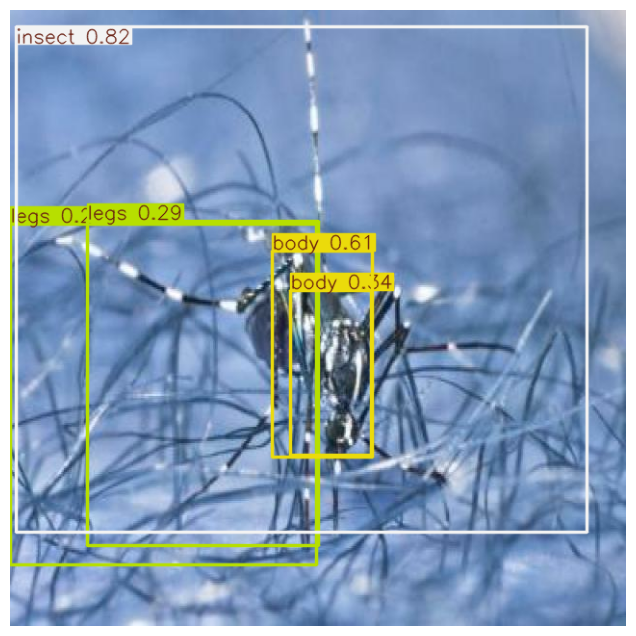

JSON guardado en: /content/drive/MyDrive/ModeloEntrenado/predictions/insect_prediction_single.json
Facts .pl guardados en: /content/drive/MyDrive/ModeloEntrenado/predictions/insect_prediction_single.pl
{
  "image_id": "aedes_albopictus_img_000281",
  "image_path": "/content/insect_dataset/insect_parts_dataset_combined/valid/images/aedes_albopictus_img_000281.jpg",
  "models_used": {
    "yolo": "/content/drive/MyDrive/ModeloEntrenado/final_models/best_yolo_insect_parts.pt",
    "mobilenet": "/content/drive/MyDrive/ModeloEntrenado/final_models/best_mobilenet_insect_multitask.pth"
  },
  "mobilenet": {
    "predicted_insect": {
      "label": "asian_tiger_mosquito",
      "confidence": 0.9199
    },
    "predicted_traits": {
      "wing_count": {
        "label": "one_pair",
        "confidence": 0.9693
      },
      "forewing_type": {
        "label": "membranous",
        "confidence": 0.9339
      },
      "mouthpart_type": {
        "label": "piercing_sucking",
        "confidence":

In [11]:
OUTPUT_JSON_PATH = PREDICTIONS_DIR / "insect_prediction_single.json"

output = predict_image_to_json(
    image_path=TEST_IMAGE,
    output_json_path=OUTPUT_JSON_PATH,
    conf=0.25,
    show=True
)

print(json.dumps(output, indent=2, ensure_ascii=False))


image 1/1 /content/insect_dataset/insect_parts_dataset_combined/valid/images/apis_mellifera_img_000113.jpg: 640x640 1 antennae, 2 bodys, 1 insect, 5 legss, 1 mouthpart, 4 wingss, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 640)


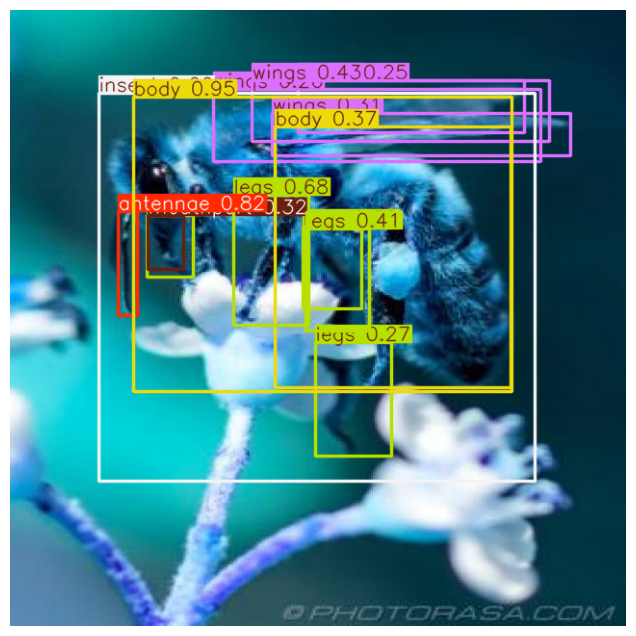

JSON guardado en: /content/drive/MyDrive/ModeloEntrenado/predictions/apis_mellifera_img_000113_prediction.json
Facts .pl guardados en: /content/drive/MyDrive/ModeloEntrenado/predictions/apis_mellifera_img_000113_prediction.pl
Insecto predicho:
{'label': 'honey_bee', 'confidence': 0.958}

Rasgos predichos:
wing_count => {'label': 'two_pairs', 'confidence': 0.9974}
forewing_type => {'label': 'membranous', 'confidence': 0.9541}
mouthpart_type => {'label': 'chewing', 'confidence': 0.9898}
antenna_type => {'label': 'filiform', 'confidence': 0.988}
leg_specialization => {'label': 'generalist', 'confidence': 0.946}
body_shape => {'label': 'elongated', 'confidence': 0.9863}
waist_shape => {'label': 'narrow_waist', 'confidence': 0.9534}

Partes detectadas:
{'body': 2, 'antennae': 1, 'legs': 5, 'insect': 1, 'wings': 4, 'mouthpart': 1}

JSON generado:
/content/drive/MyDrive/ModeloEntrenado/predictions/apis_mellifera_img_000113_prediction.json


In [12]:
target_name = "apis_mellifera_img_000113"

TEST_IMAGE = find_image_by_name(target_name)

OUTPUT_JSON_PATH = PREDICTIONS_DIR / f"{Path(TEST_IMAGE).stem}_prediction.json"

output = predict_image_to_json(
    image_path=TEST_IMAGE,
    output_json_path=OUTPUT_JSON_PATH,
    conf=0.25,
    show=True
)

print("Insecto predicho:")
print(output["mobilenet"]["predicted_insect"])

print("\nRasgos predichos:")
for trait, value in output["mobilenet"]["predicted_traits"].items():
    print(trait, "=>", value)

print("\nPartes detectadas:")
print(output["yolo"]["part_counts"])

print("\nJSON generado:")
print(OUTPUT_JSON_PATH)

In [14]:
# ==============================
# EXPORTAR VARIOS JSONS
# ==============================

from pathlib import Path
import json
import pandas as pd

# Imágenes del test
IMAGES_DIR = Path("/content/insect_dataset/insect_parts_dataset_combined/test/images")

# Guardar en Drive, NO en /content
PREDICTIONS_DIR = DRIVE_PROJECT_DIR / "predictions" / "test_jsons"
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

valid_exts = [".jpg", ".jpeg", ".png"]

image_paths = sorted([
    p for p in IMAGES_DIR.iterdir()
    if p.suffix.lower() in valid_exts
])

print("Imágenes encontradas:", len(image_paths))
print("Guardando JSONs en:", PREDICTIONS_DIR)

results_summary = []

for img_path in image_paths:
    output_json_path = PREDICTIONS_DIR / f"{img_path.stem}_prediction.json"

    try:
        output = predict_image_to_json(
            image_path=img_path,
            output_json_path=output_json_path,
            conf=0.25,
            show=False
        )

        results_summary.append({
            "image": img_path.name,
            "json_path": str(output_json_path),
            "predicted_insect": output["mobilenet"]["predicted_insect"]["label"],
            "insect_confidence": output["mobilenet"]["predicted_insect"]["confidence"],
            "part_counts": output["yolo"]["part_counts"]
        })

        print("JSON generado:", output_json_path.name)

    except Exception as e:
        print("Error con:", img_path.name)
        print(e)

SUMMARY_PATH = PREDICTIONS_DIR / "all_predictions_summary.json"

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

print("\nResumen general guardado en:")
print(SUMMARY_PATH)

display(pd.DataFrame(results_summary))

Imágenes encontradas: 34
Guardando JSONs en: /content/drive/MyDrive/ModeloEntrenado/predictions/test_jsons

image 1/1 /content/insect_dataset/insect_parts_dataset_combined/test/images/aedes_albopictus_img_000280.jpg: 640x640 1 body, 2 insects, 2 legss, 1 mouthpart, 1 wings, 9.5ms
Speed: 4.6ms preprocess, 9.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
JSON guardado en: /content/drive/MyDrive/ModeloEntrenado/predictions/test_jsons/aedes_albopictus_img_000280_prediction.json
Facts .pl guardados en: /content/drive/MyDrive/ModeloEntrenado/predictions/test_jsons/aedes_albopictus_img_000280_prediction.pl
JSON generado: aedes_albopictus_img_000280_prediction.json

image 1/1 /content/insect_dataset/insect_parts_dataset_combined/test/images/aedes_albopictus_img_000289.jpg: 640x640 1 antennae, 1 body, 2 insects, 3 legss, 1 mouthpart, 11.7ms
Speed: 3.3ms preprocess, 11.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
JSON guardado en: /content/drive/MyDr

,image,json_path,predicted_insect,insect_confidence,part_counts
0,aedes_albopictus_img_000280.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,asian_tiger_mosquito,0.9804,"{'body': 1, 'wings': 1, 'insect': 2, 'legs': 2..."
1,aedes_albopictus_img_000289.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,asian_tiger_mosquito,0.8178,"{'insect': 2, 'body': 1, 'legs': 3, 'antennae'..."
2,aedes_albopictus_img_000293.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,asian_tiger_mosquito,0.4347,"{'body': 1, 'legs': 4, 'insect': 2, 'antennae'..."
3,aedes_albopictus_img_000302.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,asian_tiger_mosquito,0.9711,"{'wings': 1, 'body': 1, 'insect': 1, 'legs': 4..."
4,aedes_albopictus_img_000304.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,asian_tiger_mosquito,0.9428,"{'wings': 1, 'body': 2, 'legs': 7, 'insect': 1}"
5,aedes_albopictus_img_000317.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,asian_tiger_mosquito,0.9752,"{'body': 1, 'insect': 1, 'legs': 2, 'mouthpart..."
6,apis_mellifera_img_000123.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,honey_bee,0.8306,"{'antennae': 2, 'insect': 1, 'body': 2, 'wings..."
7,apis_mellifera_img_000128.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,honey_bee,0.9166,"{'body': 1, 'insect': 1, 'legs': 4, 'wings': 2..."
8,apis_mellifera_img_000129.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,honey_bee,0.9815,"{'insect': 1, 'wings': 3, 'antennae': 3, 'body..."
9,apis_mellifera_img_000144.jpg,/content/drive/MyDrive/ModeloEntrenado/predict...,honey_bee,0.9355,"{'insect': 1, 'antennae': 1, 'legs': 2, 'wings..."
